# L6 Regular Expressions

- Why work with text?

- Python String Methods

- RegEx

- RegEx in Python & Pandas (RegEx Groups)

- Limitations

## 1 Why work with text?

- **Canonicalization**: Convert data with multiple formats into a standard form

	- Standardization is more like using one way to treat different entities, canonicalization is more like one entity may have different way to showcase, but we determine on one form as the convention

- **Extract the information** into a new feature from text

## 2 Python String Methods

- The Python functions **operate on a single string**

| Operation | Python | `Pandas` (`Series`) |
| --- | --- | --- |
| Transformation |  `s.lower()`  `s.upper()` |  `ser.str.lower()`  `ser.str.upper()` |
| Replacement + Deletion | `s.replace(_)` | `ser.str.replace(_)` |
| Split | `s.split(_)` | `ser.str.split(_)` |
| Substring | `s[1:4]` | `ser.str[1:4]` |
| Membership | `'_' in s` | `ser.str.contains(_)` |
| Length | `len(s)` | `ser.str.len()` |

- Their equivalent in pandas are **vectorized** — they operate on a **Series** of string data

- `.str` method is also an accessor, similar to `.dt`

### Canonicalization

In [9]:
import pandas as pd
import numpy as np

with open('county_and_state.csv') as f:
    county_and_state = pd.read_csv(f)
    
with open('county_and_population.csv') as f:
    county_and_pop = pd.read_csv(f)

display(county_and_state), display(county_and_pop)

# You can try display(county_and_state), display(county_and_pop);
# ; 在 Python 语法上只是“语句分隔符”，不是必须的
# 但在 Jupyter/IPython 里，行尾 ; 还有“隐藏最后输出”的特殊行为

,County,State
0,De Witt County,IL
1,Lac qui Parle County,MN
2,Lewis and Clark County,MT
3,St John the Baptist Parish,LS


,County,Population
0,DeWitt,16798
1,Lac Qui Parle,8067
2,Lewis & Clark,55716
3,St. John the Baptist,43044


(None, None)

- `De Witt County` & `DeWitt` are the same but in different forms

- Need to convert them into one cononical form

**Canonicalization with Python String Manipulation**

- It does so by eliminating whitespace, punctuation, and unnecessary text

In [10]:
def canonicalize_county(county_name):
    return (
        county_name
            .lower()
            .replace(' ', '')
            .replace('&', 'and')
            .replace('.', '')
            .replace('county', '')
            .replace('parish', '')
    )

canonicalize_county("St. John the Baptist")

'stjohnthebaptist'

**Canonicalization with Pandas Series Methods**

- We can use pandas Series methods to create this standardized column

  - Call the `.str` attribute of our Series object (Accessor)
  
  - Then call the methods, like `.lower` & `.replace`

- C**haining multiple Series methods** in this manner eliminates the need to use the `map` function

In [ ]:
def canonicalize_county_series(county_series):
    return (
        county_series
            .str.lower() # All lowercase
            .str.replace(' ', '') # Eliminate all whitespaces
            .str.replace('&', 'and') # Replace & with and
            .str.replace('.', '') # Eliminate all periods
            .str.replace('county', '') # Eliminate all instances of 'county'
            .str.replace('parish', '') # Eliminate all instances of 'parish'
    )

county_and_pop['clean_county_pandas'] = canonicalize_county_series(county_and_pop['County'])
county_and_state['clean_county_pandas'] = canonicalize_county_series(county_and_state['County'])
display(county_and_pop), display(county_and_state) # This will also entail a tuple since ,

,County,Population,clean_county_pandas
0,DeWitt,16798,dewitt
1,Lac Qui Parle,8067,lacquiparle
2,Lewis & Clark,55716,lewisandclark
3,St. John the Baptist,43044,stjohnthebaptist


,County,State,clean_county_pandas
0,De Witt County,IL,dewitt
1,Lac qui Parle County,MN,lacquiparle
2,Lewis and Clark County,MT,lewisandclark
3,St John the Baptist Parish,LS,stjohnthebaptist


(None, None)

### Extraction

- Say we want to read some data from a `.txt` file

In [14]:
with open('log.txt', 'r') as f:
    log_lines = f.readlines()

log_lines

['169.237.46.168 - - [26/Jan/2014:10:47:58 -0800] "GET /stat141/Winter04/ HTTP/1.1" 200 2585 "http://anson.ucdavis.edu/courses/"\n',
 '193.205.203.3 - - [2/Feb/2005:17:23:6 -0800] "GET /stat141/Notes/dim.html HTTP/1.0" 404 302 "http://eeyore.ucdavis.edu/stat141/Notes/session.html"\n',
 '169.237.46.240 - "" [3/Feb/2006:10:18:37 -0800] "GET /stat141/homework/Solutions/hw1Sol.pdf HTTP/1.1"\n']

- Say we want to extract the day, month, year, hour, minutes, seconds, and time zone

- Since items are not in the fixed position in a string, we cannot simply use slicing

- But we can notice there are some patterns for the specific information, we **select the info based on the string patterns**!

	- **e.g.** The time relevant information is contained in `[26/Jan/2014:10:47:58 -0800]`
    	
		- Within `[]`
    	
		- Separated by `/` and `:`

In [15]:
first = log_lines[0] # Only considering the first row of data

pertinent = first.split("[")[1].split(']')[0]
day, month, rest = pertinent.split('/')
year, hour, minute, rest = rest.split(':')
seconds, time_zone = rest.split(' ')
day, month, year, hour, minute, seconds, time_zone

('26', 'Jan', '2014', '10', '47', '58', '-0800')

- But Python's built-in funcs can only extract data from **one record at a time**

- And the code is quite verbose (A larger problem!)

- RegEx is more delicate

## 3 RegEx `re`

- A **regular expression (“RegEx”, 正则表达式)** is a sequence of characters that **specifies a search pattern**

In [16]:
r"[0-9]{3}-[0-9]{2}-[0-9]{4}" # Regular Expression Syntax

# 3 of any digit, then a dash,
# then 2 of any digit, then a dash,
# then 4 of any digit

'[0-9]{3}-[0-9]{2}-[0-9]{4}'

Some references:

- [Official RegEx Guide](https://docs.python.org/3/howto/regex.html)

- [Data 100 Reference Sheet](https://ds100.org/sp22/resources/assets/hw/regex_reference.pdf)

- [RegEx101.com](https://regex101.com/)

### Basics RegEx Syntax

- focus on e.g. and matches

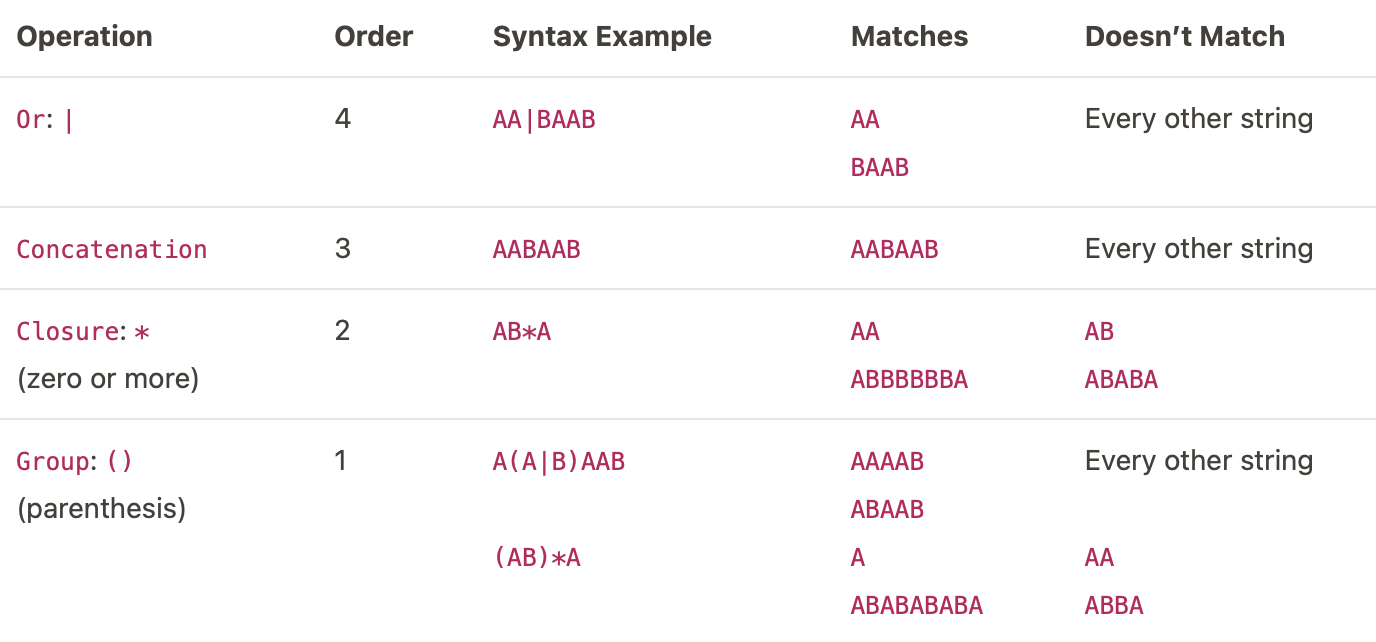



- Rather than being literal characters, these **metacharacters (元字符)** manipulate adjacent characters (`()` takes precedence, followed by `*`, and finally `|`)

**e.g.** `AB*` and `(AB)*`

- `AB*` is `A` and 0 or many `B`: A, AB, ABBB

- `(AB)*` is 0 or many `AB`: None, AB, ABABAB

### RegEx Expanded

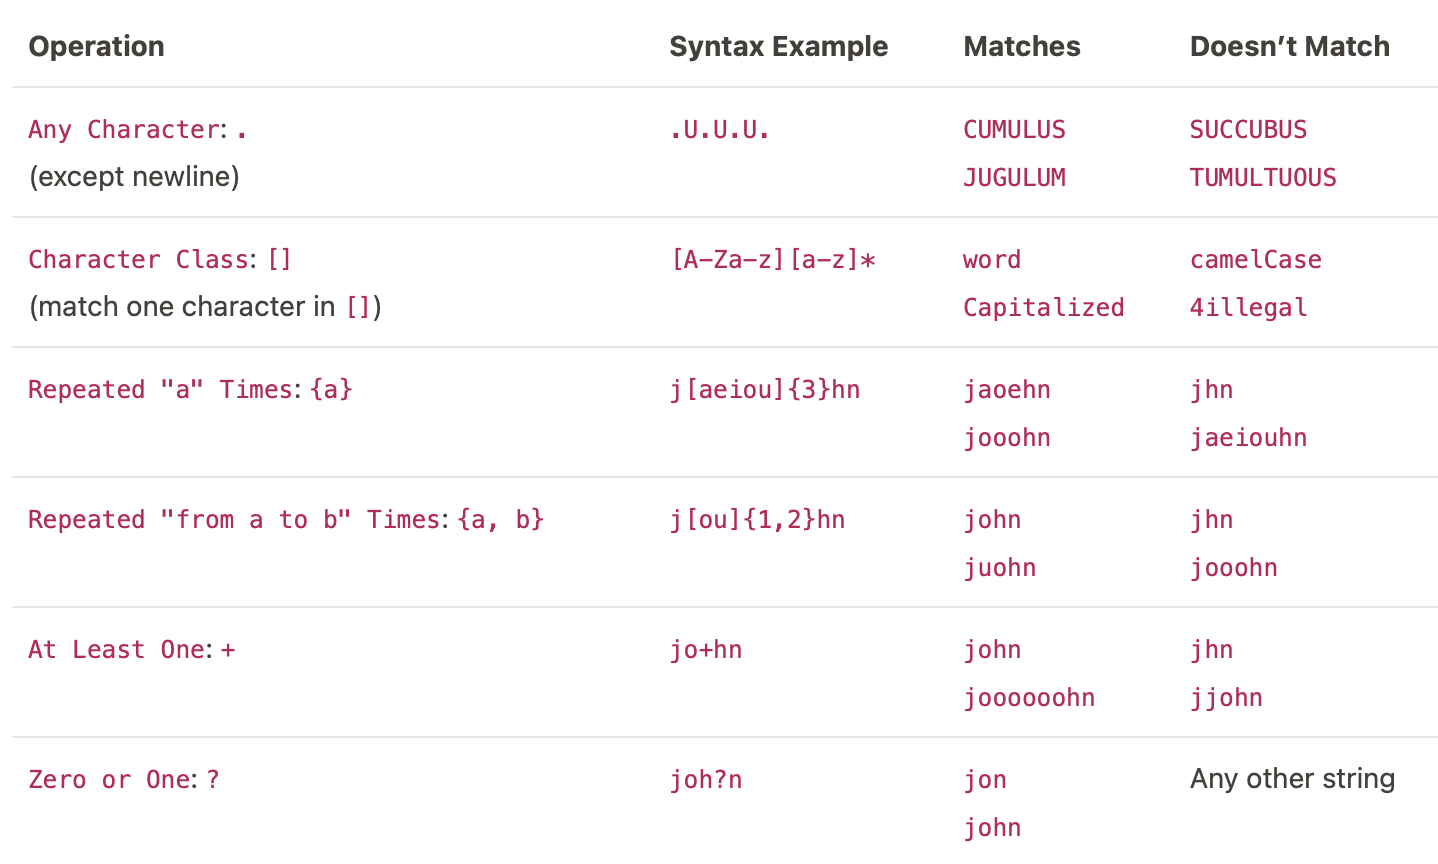

**Character Class Shorthands**

- `[A-Z]`: Any capitalized letter

- `[a-z]`: Any lowercase letter

- `[0-9]`: Any single digit

- `[S]{n}`: Exactly n times showed in the set S

- `[S]{n, m}`: From n to m times showed in the set S

- `[S]+`: 1+ times showed in S

- `[S]?`: 0 or 1 time showed in S

**You can combine them together**

- `[A-Za-z]`: Any capitalized or lowercase letter

- `[A-Za-z0-9]`: Any capitalized or lowercase letter or single digit

**e.g.**

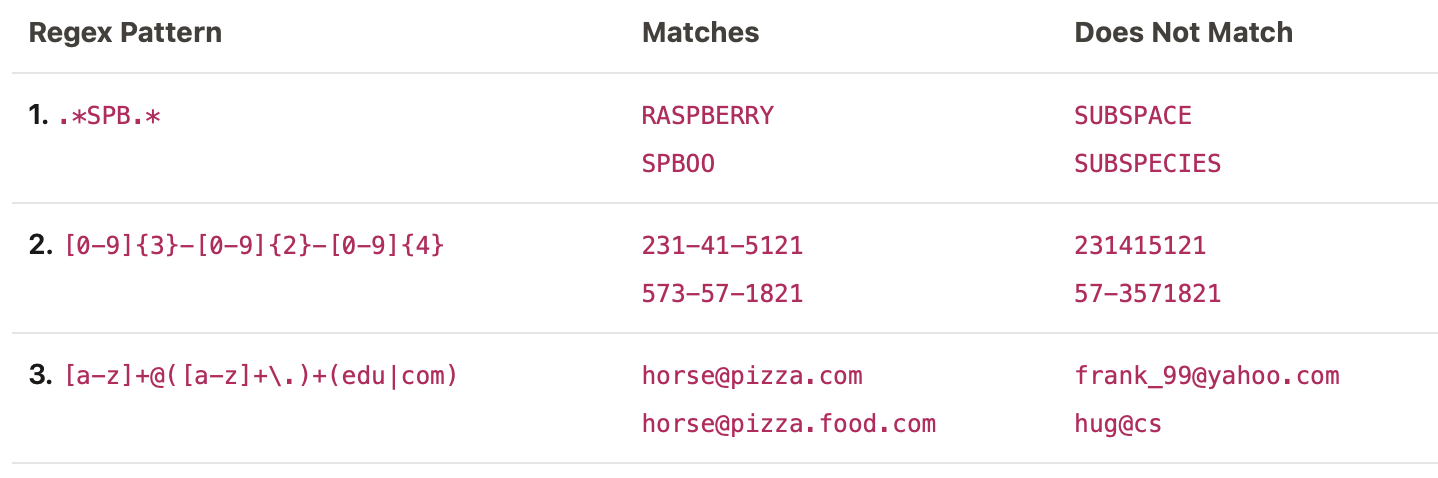

- `.*SPB.*` only matches strings that contain the substring `SPB`

- `[0-9]{3}-[0-9]{2}-[0-9]{4}` matches 3 of any digit, then a dash, then 2 of any digit, then a dash, then 4 of any digit

- `[a-z]+@([a-z]+\.)+(edu|com)` matches any email with a com or edu domain, where all characters of the email are letters

### Convenient RegEx

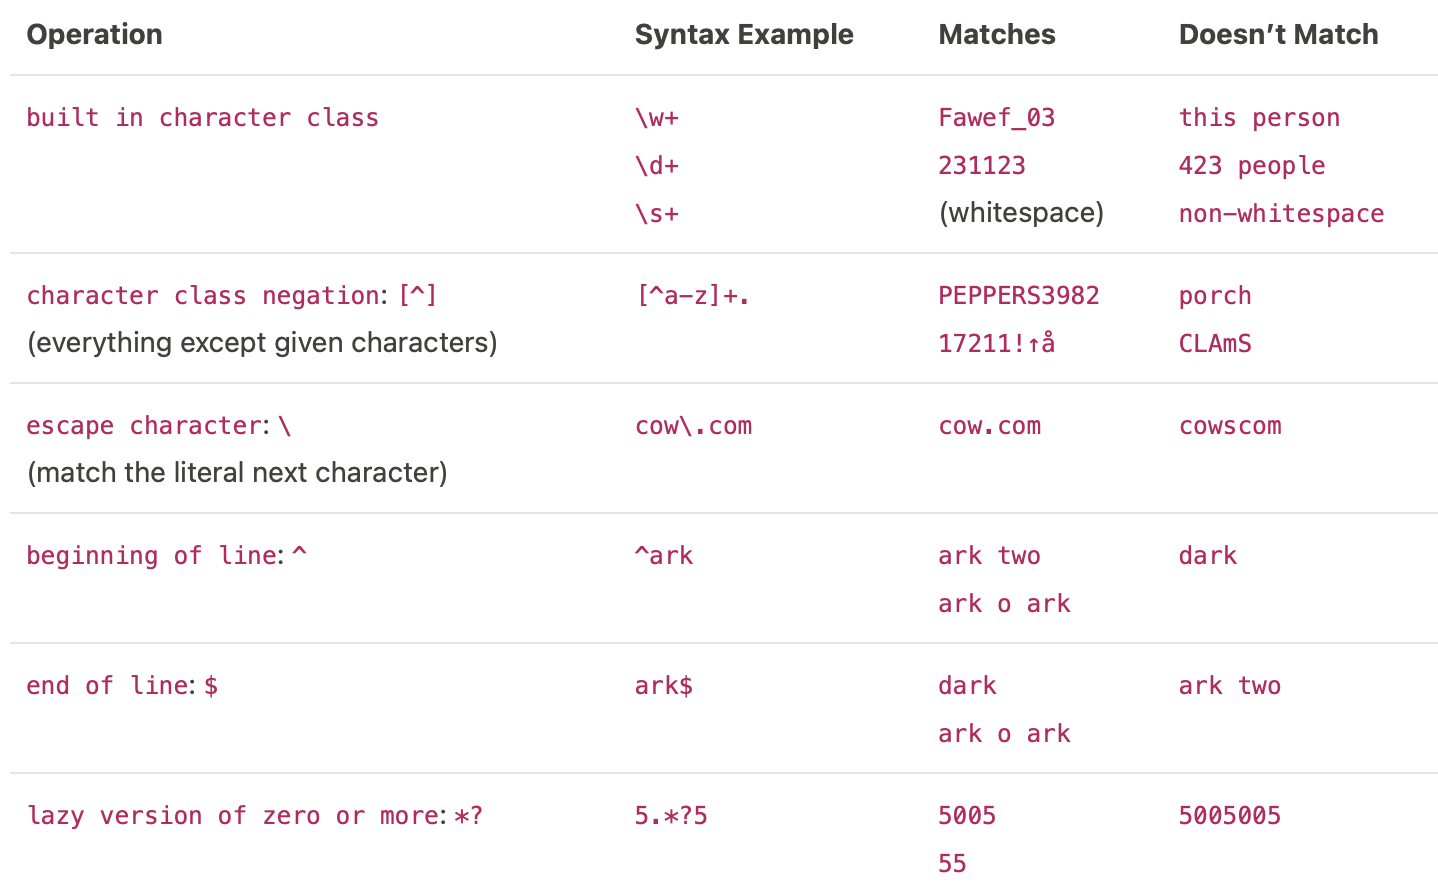

- `\w+`: one or more consecutive word characters (`\w` is one word character, including Unicode characters)

- `\d`: One digit character, i.e. `[0-9]`

- `\s`: One space, tab `\t`, newline `\n`

### Greediness

- RegEx is greedy – it will **look for the longest possible match** in a string

- RegEx quantifiers such as `*`, `+`, and `{}` are greedy

- This means **it will scam through whole text** to do it

**e.g.** `<div>.*</div>`

- We may hope that the two bolded portions would be matched separately like:

“This is a **`<div>example</div>`** of greediness **`<div>in</div>`** regular expressions.”

- But actually, the longest one is:

“This is a **`<div>example</div> of greediness <div>in</div>`** regular expressions.”

- We can fix it by using lazy version: `<div>.*?</div>`

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **Greedy & Lazy**

- Say a given string `aaaa`

-  `a+` can match: `a`, `aa`, `aaa`, `aaaa`

- There is a "where to stop" issue

- RegEx will match the longest until it cannot, so `aaaa`

- For lazy one `a+?`

  - It will run `+` and match `a` first then try `?`

  - Once `?` is satisfied, it will escape the procedure so no more `+`

</div>

In [17]:
# Let's look back at the .txt file we read in earlier
log_lines[0]

'169.237.46.168 - - [26/Jan/2014:10:47:58 -0800] "GET /stat141/Winter04/ HTTP/1.1" 200 2585 "http://anson.ucdavis.edu/courses/"\n'

- A regular expression that matches everything contained within and including the brackets - the day, month, year, hour, minutes, seconds, and time zone:

	`\[.*\]`

- Remember to add `\` or `[]` will indicate character classes

- Another safer but stricter solution：`\[\w+/\w+/\w+:\w+:\w+:\w+\s-\w+\]`


## 4 RegEx Groups

- We can **use RegEx to search multiple strings** at once

### Canonicalization

**Substitute Function: `re.sub(pattern, rep1, text)`**

- Similar to `.replace` and return all instances of `pattern` replaced by `rep1`

**e.g.** Removes text surrounded by `<>` (also known as HTML tags)

**Patterns:**

- Match a single `<`

- Match any character that is not a `>` like div, td valign..., /td, /div

- Match a single `>`

Any substring in text fulfills this pattern need to be replaced by `''`

In [ ]:
import re

text = "<div><td valign='top'>Moo</td></div>"
pattern = r"<[^>]+>" # r specifies the regular expression is a raw string
# Raw strings do not recognize escape sequences (\n, \t, etc.) and treat them as literal characters

re.sub(pattern, '', text) 

'Moo'

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- Don’t forget to tag your RegEx with an `r`

</div>

- We can also **combine RegEx with pandas to modify multiple entries** at once

In [20]:
data = {"HTML": ["<div><td valign='top'>Moo</td></div>", \
                 "<a href='http://ds100.org'>Link</a>", \
                 "<b>Bold text</b>"]}
html_data = pd.DataFrame(data)

html_data

,HTML
0,<div><td valign='top'>Moo</td></div>
1,<a href='http://ds100.org'>Link</a>
2,<b>Bold text</b>


In [21]:
pattern = r"<[^>]+>"
html_data['HTML'].str.replace(pattern, '', regex=True)

0          Moo
1         Link
2    Bold text
Name: HTML, dtype: object

### Extraction

**`re.findall(pattern, text)`**

- It returns a **list of all matches** to pattern

In [22]:
text = "My social security number is 123-45-6789 bro, or maybe it’s 321-45-6789."
pattern = r"[0-9]{3}-[0-9]{2}-[0-9]{4}"

re.findall(pattern, text)  

['123-45-6789', '321-45-6789']

**`ser.str.findall(pattern)`**

- It returns **a list for every row containing the pattern matches in a given string**

In [24]:
data = {"SSN": ["987-65-4321", "forty", \
                "123-45-6789 bro or 321-45-6789",
               "999-99-9999"]}

ssn_data = pd.DataFrame(data)

ssn_data

,SSN
0,987-65-4321
1,forty
2,123-45-6789 bro or 321-45-6789
3,999-99-9999


In [25]:
ssn_data["SSN"].str.findall(pattern)

0                 [987-65-4321]
1                            []
2    [123-45-6789, 321-45-6789]
3                 [999-99-9999]
Name: SSN, dtype: object

**`Series.str.extract`**

- It takes in a pattern and returns a DataFrame of **each capture group’s first match** in the string

In [26]:
pattern_cg = r"([0-9]{3})-([0-9]{2})-([0-9]{4})"
ssn_data["SSN"].str.extract(pattern_cg)

,0,1,2
0,987,65,4321
1,NaN,NaN,NaN
2,123,45,6789
3,999,99,9999


**`Series.str.extractall`**

- It returns a multi-indexed DataFrame of all matches for each capture group

In [27]:
ssn_data["SSN"].str.extractall(pattern_cg)

0   1     2
  match               
0 0      987  65  4321
2 0      123  45  6789
  1      321  45  6789
3 0      999  99  9999

### RegEx Capture Groups

- `()` can also be used to represent **capture groups (捕获组)**

- Basically tell python to seperate the strings after captured by RegEx

In [28]:
text = "Observations: 03:04:53 - Horse awakens. \
        03:05:14 - Horse goes back to sleep."

- Say we want to capture all occurences of time data (hour, minute, and second) as **separate entities**

- 整个 regex 匹配的是完整的 `03:04:53`，但括号让 Python 顺便把内部三部分单独“抓出来”

In [29]:
pattern_1 = r"(\d\d):(\d\d):(\d\d)"
re.findall(pattern_1, text)

[('03', '04', '53'), ('03', '05', '14')]

In [32]:
pattern_2 = r"(\d\d):(\d\d):(\d{2})"
re.findall(pattern_2, text)

[('03', '04', '53'), ('03', '05', '14')]

In [33]:
pattern_2 = r"(\d\d):(\d\d):(\d{1})"
re.findall(pattern_2, text)

[('03', '04', '5'), ('03', '05', '1')]

Another e.g.

In [34]:
first = log_lines[0]
first

'169.237.46.168 - - [26/Jan/2014:10:47:58 -0800] "GET /stat141/Winter04/ HTTP/1.1" 200 2585 "http://anson.ucdavis.edu/courses/"\n'

In [35]:
pattern = r'\[(\d+)\/(\w+)\/(\d+):(\d+):(\d+):(\d+) (.+)\]'
day, month, year, hour, minute, second, time_zone = re.findall(pattern, first)[0]
print(day, month, year, hour, minute, second, time_zone)

26 Jan 2014 10 47 58 -0800


## 5 Limitations

- RegEx are hard to read and debug

- Regular expressions are terrible at certain types of problems

	- For **parsing a hierarchical structure**, such as JSON, use the `json.load()` parser, not RegEx!

	- Complex features (e.g. valid email address)

  -  Traditional RegEx **doesn't have memory**
    
     	- Counting (same number of instances of a and b). (**impossible**)
         	
     		- ab (1), aabb (2), aaabbb (3)...
     	
     	- Complex properties (palindromes (回文), balanced parentheses). (**impossible**)

			```	
			(()
			())(
			```

---
[Reference](https://ds100.org/course-notes/regex/#regex-basics)